# xG-Projekt - 03: Feature-Vorbereitung & Modelltraining

Deckt die Anforderungen **4 (Feature Engineering: Bereinigen & Transformieren)**,
**5 (Modelltraining)** und **6 (Modellevaluierung per Kreuzvalidierung)** ab.

Vergleich von Logistic Regression (Baseline) vs. Random Forest vs.
XGBoost, jeweils mit stratifizierter Kreuzvalidierung.


## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss, roc_curve
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

df = pd.read_csv("../data/shots.csv")
print(df.shape)


(916, 17)


## 1. Bereinigen

`n_defenders_in_cone` und `gk_distance_to_goal` fehlen bei einer Handvoll Schüssen (v.a.
Elfmeter ohne vollständiges Freeze-Frame). Ich imputieren mit dem Median statt die Zeilen zu
verwerfen, um keine Trainingsdaten zu verlieren.


In [2]:
print("Fehlende Werte vorher:")
print(df[["n_defenders_in_cone", "gk_distance_to_goal"]].isna().sum())

df["n_defenders_in_cone"] = df["n_defenders_in_cone"].fillna(df["n_defenders_in_cone"].median())
df["gk_distance_to_goal"] = df["gk_distance_to_goal"].fillna(df["gk_distance_to_goal"].median())

# Seltene Kategorien in shot_type/technique zu 'Other' zusammenfassen (robuster für One-Hot)
df["shot_type"] = df["shot_type"].fillna("Open Play")
df["technique"] = df["technique"].fillna("Normal")

print("\nFehlende Werte nachher:", df[["n_defenders_in_cone", "gk_distance_to_goal"]].isna().sum().sum())


Fehlende Werte vorher:
n_defenders_in_cone    8
gk_distance_to_goal    8
dtype: int64

Fehlende Werte nachher: 0


## 2. Transformieren: Feature-Matrix bauen

- Numerische Features bleiben wie sie sind 
- Kategoriale Features (`body_part`, `shot_type`, `technique`, `play_pattern`) werden per
  One-Hot-Encoding umgewandelt
- `statsbomb_xg`, `player`, `team`, `match_id`, `minute` werden **nicht** als Features
  verwendet (Datenleck bzw. keine sinnvollen Prädiktoren für eigenes Modell)


In [3]:
numeric_features = ["distance_to_goal", "angle_to_goal", "n_defenders_in_cone", "gk_distance_to_goal"]
categorical_features = ["body_part", "shot_type", "technique", "play_pattern"]
binary_features = ["under_pressure"]

X_numeric = df[numeric_features + binary_features].copy()
X_numeric["under_pressure"] = X_numeric["under_pressure"].astype(int)

X_categorical = pd.get_dummies(df[categorical_features], drop_first=True)

X = pd.concat([X_numeric, X_categorical], axis=1)
y = df["is_goal"]

print(f"Feature-Matrix: {X.shape[0]} Schüsse, {X.shape[1]} Features")
X.head(3)


Feature-Matrix: 916 Schüsse, 23 Features


,distance_to_goal,angle_to_goal,n_defenders_in_cone,gk_distance_to_goal,under_pressure,body_part_Left Foot,body_part_Other,body_part_Right Foot,shot_type_Open Play,shot_type_Penalty,...,technique_Overhead Kick,technique_Volley,play_pattern_From Counter,play_pattern_From Free Kick,play_pattern_From Goal Kick,play_pattern_From Keeper,play_pattern_From Kick Off,play_pattern_From Throw In,play_pattern_Other,play_pattern_Regular Play
0,18.669762,17.365796,1.0,3.612478,1,False,False,True,True,False,...,False,False,False,False,False,False,False,False,False,True
1,23.500213,19.319453,2.0,2.220360,1,False,False,True,True,False,...,False,False,False,False,False,False,False,True,False,False
2,32.272124,13.932473,3.0,2.433105,1,False,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False


## 3. Train/Test-Split

Stratifiziert nach `is_goal`, damit das Klassenverhältnis (~12% Tore) in beiden Teilmengen
erhalten bleibt.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} ({y_train.mean()*100:.1f}% Tore)")
print(f"Test:  {len(X_test)} ({y_test.mean()*100:.1f}% Tore)")


Train: 732 (12.0% Tore)
Test:  184 (12.0% Tore)


## 4. Modelltraining

Drei Modelle, aufsteigende Komplexität:
1. **Logistic Regression** – Baseline, interpretierbar, entspricht dem klassischen
   statistischen xG-Ansatz 
2. **Random Forest** – nicht-linear, robust, wenig Tuning nötig
3. **XGBoost** – Gradient Boosting, in der Praxis meist das stärkste Modell für xG
   (StatsBomb/Opta nutzen intern ähnliche Gradient-Boosting-Ansätze)


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=10, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

xgb = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    eval_metric="logloss", random_state=RANDOM_STATE
)
xgb.fit(X_train, y_train)

print("Alle drei Modelle trainiert.")


Alle drei Modelle trainiert.


## 5. Modellevaluierung auf dem Test-Set

Wegen des Klassenungleichgewichts (~12% Tore) ist Accuracy irreführend (ein Modell, das immer
"kein Tor" vorhersagt, hätte schon ~88% Accuracy. Deswegen:

- **ROC-AUC**: Fähigkeit, Tore von Nicht-Toren zu unterscheiden, unabhängig vom Schwellenwert
- **Log-Loss**: Standardmetrik für xG-Modelle in der Praxis, bestraft übermütige Fehleinschätzungen
- **Brier Score**: mittlerer quadratischer Fehler der Wahrscheinlichkeitsschätzung (Kalibrierung)


In [6]:
def evaluate(name, y_true, y_proba):
    return {
        "Modell": name,
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "Log-Loss": log_loss(y_true, y_proba),
        "Brier Score": brier_score_loss(y_true, y_proba),
    }

results = [
    evaluate("Logistic Regression", y_test, log_reg.predict_proba(X_test_scaled)[:, 1]),
    evaluate("Random Forest", y_test, rf.predict_proba(X_test)[:, 1]),
    evaluate("XGBoost", y_test, xgb.predict_proba(X_test)[:, 1]),
]

results_df = pd.DataFrame(results).set_index("Modell").round(4)
results_df


,ROC-AUC,Log-Loss,Brier Score
Modell,,,
Logistic Regression,0.7904,0.2809,0.0801
Random Forest,0.8173,0.3035,0.0897
XGBoost,0.7518,0.2939,0.0795


In [ ]:
# Vergleich mit StatsBombs eigenem xG-Wert auf denselben Test-Schüssen
sb_xg_test = df.loc[X_test.index, "statsbomb_xg"]
sb_result = evaluate("StatsBomb xG (Referenz)", y_test, sb_xg_test.fillna(sb_xg_test.mean()))
print(pd.Series(sb_result))


Modell         StatsBomb xG (Referenz)
ROC-AUC                       0.820146
Log-Loss                      0.265504
Brier Score                   0.073559
dtype: object


## 6. ROC-Kurven im Vergleich


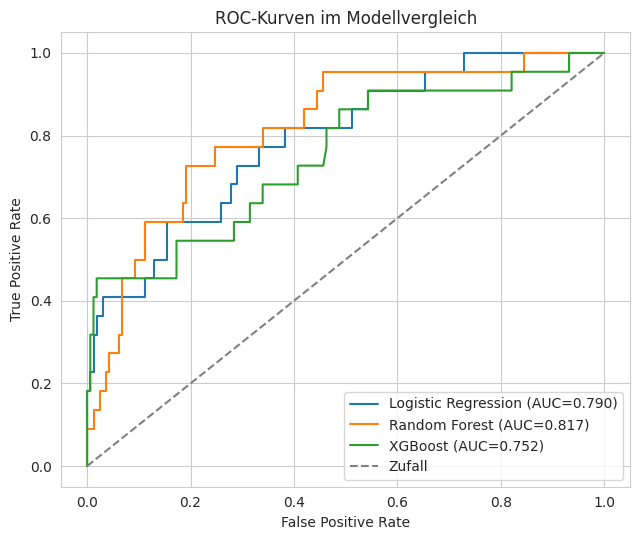

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for name, proba in [
    ("Logistic Regression", log_reg.predict_proba(X_test_scaled)[:, 1]),
    ("Random Forest", rf.predict_proba(X_test)[:, 1]),
    ("XGBoost", xgb.predict_proba(X_test)[:, 1]),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Zufall")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-Kurven im Modellvergleich")
ax.legend()
plt.tight_layout()
plt.savefig("../plots/08_roc_curves.png")
plt.show()


## 7. Kreuzvalidierung (Anforderung 6)

Ein einzelner Train/Test-Split kann durch Zufall günstig oder ungünstig ausfallen,
besonders bei nur ~900 Schüssen. Deshalb validiert mit **5-fach stratifizierter
Kreuzvalidierung** auf dem gesamten Datensatz, um eine robustere Einschätzung zu bekommen


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "neg_log_loss": "neg_log_loss"}

cv_results = {}

for name, model, data in [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), scaler.fit_transform(X)),
    ("Random Forest", RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=10, random_state=RANDOM_STATE), X),
    ("XGBoost", XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, eval_metric="logloss", random_state=RANDOM_STATE), X),
]:
    scores = cross_validate(model, data, y, cv=cv, scoring=scoring)
    cv_results[name] = {
        "ROC-AUC (Mittel)": scores["test_roc_auc"].mean(),
        "ROC-AUC (Std)": scores["test_roc_auc"].std(),
        "Log-Loss (Mittel)": -scores["test_neg_log_loss"].mean(),
    }

cv_results_df = pd.DataFrame(cv_results).T.round(4)
cv_results_df


,ROC-AUC (Mittel),ROC-AUC (Std),Log-Loss (Mittel)
Logistic Regression,0.7725,0.0243,0.3066
Random Forest,0.7809,0.0330,0.3115
XGBoost,0.7203,0.0102,0.3399


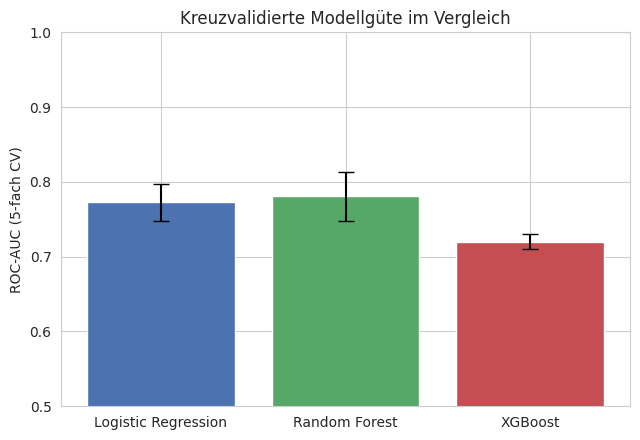

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(cv_results_df.index, cv_results_df["ROC-AUC (Mittel)"],
       yerr=cv_results_df["ROC-AUC (Std)"], capsize=6, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("ROC-AUC (5-fach CV)")
ax.set_title("Kreuzvalidierte Modellgüte im Vergleich")
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig("../plots/09_cv_comparison.png")
plt.show()


## 8. Feature Importance (bestes Modell)

Welche Features tragen am meisten zur Vorhersage bei? 


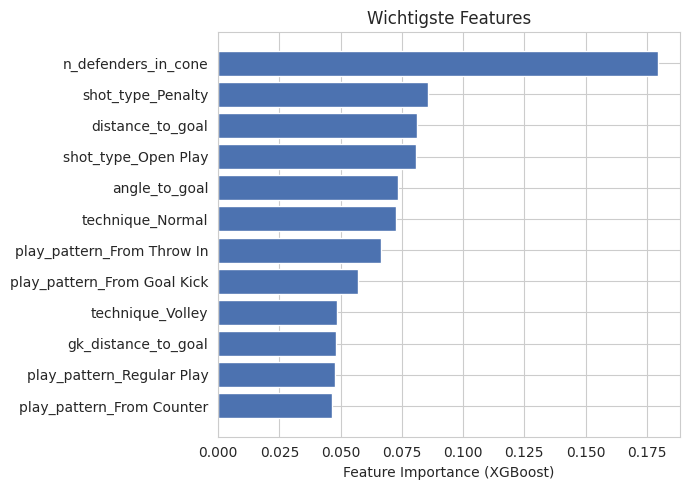

In [11]:
importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(importances.index[::-1], importances.values[::-1], color="#4C72B0")
ax.set_xlabel("Feature Importance (XGBoost)")
ax.set_title("Wichtigste Features")
plt.tight_layout()
plt.savefig("../plots/10_feature_importance.png")
plt.show()
